# Stage 1 · Portfolio choice

Executed companion to the latest reviewed **four-page** report:
[`Stage1_Portfolio_Choice_1007.pdf`](../reports/stage1/Stage1_Portfolio_Choice_1007.pdf).
It uses 29 stocks from the 31 October 2015 DJIA cohort, retaining six later index
removals. Old E. I. du Pont is excluded for an identity-consistent history gap;
UTX continues as RTX. The sample is November 2015–August 2026, 130 monthly USD
returns. See the [methods](../docs/DATA_AND_METHODS.md) and
[collaborator handoff](../docs/COLLABORATOR_HANDOFF.md) for source and unit definitions.

Run the cells in order. The first code cell invokes the offline reproduction and
independent validation pipeline. It updates numeric outputs and figures, and
leaves the manually edited PDF unchanged. No new data is downloaded.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image

candidates = []
for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates.extend([parent / 'stage1', parent])
ROOT = next((p for p in candidates
             if (p / 'tools/reproduce_stage1.py').is_file()
             and (p / 'config/universe.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Open the repository root, stage1 folder or Stage 1 notebook folder.')
completed = subprocess.run([sys.executable, '-X', 'utf8',
                           str(ROOT / 'tools/reproduce_stage1.py')],
                           cwd=ROOT, capture_output=True, text=True, encoding='utf-8')
if completed.returncode:
    message = completed.stderr.replace(str(ROOT), '<repository>').replace(ROOT.as_posix(), '<repository>')
    raise RuntimeError('Reproduction failed: ' + message)
receipt = json.loads((ROOT / 'validation/reproduction.json').read_text(encoding='utf-8'))
assert receipt['status'] == 'pass'
print('Offline reproduction and independent validation passed.')

def table(relative):
    return pd.read_csv(ROOT / relative, float_precision='round_trip')

config = json.loads((ROOT / 'config/universe.json').read_text(encoding='utf-8'))
returns = table('data/processed/returns_us_monthly.csv').set_index('Month')
factors = table('data/processed/ff3_monthly.csv').set_index('Month')
assert returns.index.equals(factors.index) and returns.shape == (130, 29)
print({'stocks': returns.shape[1], 'months': returns.shape[0],
       'first_month': returns.index[0], 'last_month': returns.index[-1]})

Offline reproduction and independent validation passed.
{'stocks': 29, 'months': 130, 'first_month': '2015-11', 'last_month': '2026-08'}


## 1a · Summary statistics

Estimate the **arithmetic monthly** mean vector and sample covariance from raw
stock returns. For the full sample,

\[
\hat{\mu}=\frac{1}{130}\sum_{t=1}^{130}\mathbf R_t,
\qquad
\hat{\Sigma}=\frac{1}{129}\sum_{t=1}^{130}
(\mathbf R_t-\hat{\mu})(\mathbf R_t-\hat{\mu})^{\mathsf T}.
\]

The table below displays monthly percentages, matching Table 1.1. All
calculations retain full precision; only displays round to three decimals.

In [2]:
summary = table('results/stage1/exhibit_1a_summary_stats.csv').set_index('ticker')
removed = {'GE', 'XOM', 'PFE', 'RTX', 'INTC', 'VZ'}
monthly = summary[['mean_monthly', 'volatility_monthly']].mul(100)
monthly.columns = ['Mean % (monthly)', 'Volatility % (monthly)']
monthly['Later index removal'] = monthly.index.isin(removed)
display(monthly.round(3))

,Mean % (monthly),Volatility % (monthly),Later index removal
ticker,,,
MMM,0.703,6.887,False
AXP,1.566,7.517,False
AAPL,2.226,7.917,False
BA,0.977,11.099,False
CAT,2.465,9.210,False
CVX,1.305,8.001,False
CSCO,1.533,7.120,False
KO,0.937,4.613,False
XOM,1.183,7.940,True


## 1b · Portfolio weights and performance

The unrestricted tangency direction solves the raw covariance system for the
estimated excess mean. Normalization gives weights summing to one:

\[
z=\hat{\Sigma}^{-1}(\hat{\mu}-\overline{R_F}\mathbf 1),
\qquad w_F=\frac{z}{\mathbf 1^{\mathsf T}z}.
\]

Value weights use fixed Yahoo company capitalizations on 31 August 2026.
Long-only tangency maximizes the same model Sharpe with nonnegative weights
summing to one. Each portfolio rebalances to its fixed target weights monthly.

The main Sharpe formula uses annualized arithmetic means and **raw-return**
volatility:

\[
S_{\mathrm{model}}=
\frac{\hat\mu_{p,\mathrm{ann}}-\hat\mu_{RF,\mathrm{ann}}}
{\hat\sigma_{p,\mathrm{ann}}}.
\]

Monthly means are multiplied by 12 and monthly volatility by the square root
of 12. This is not a compounded growth-rate calculation.

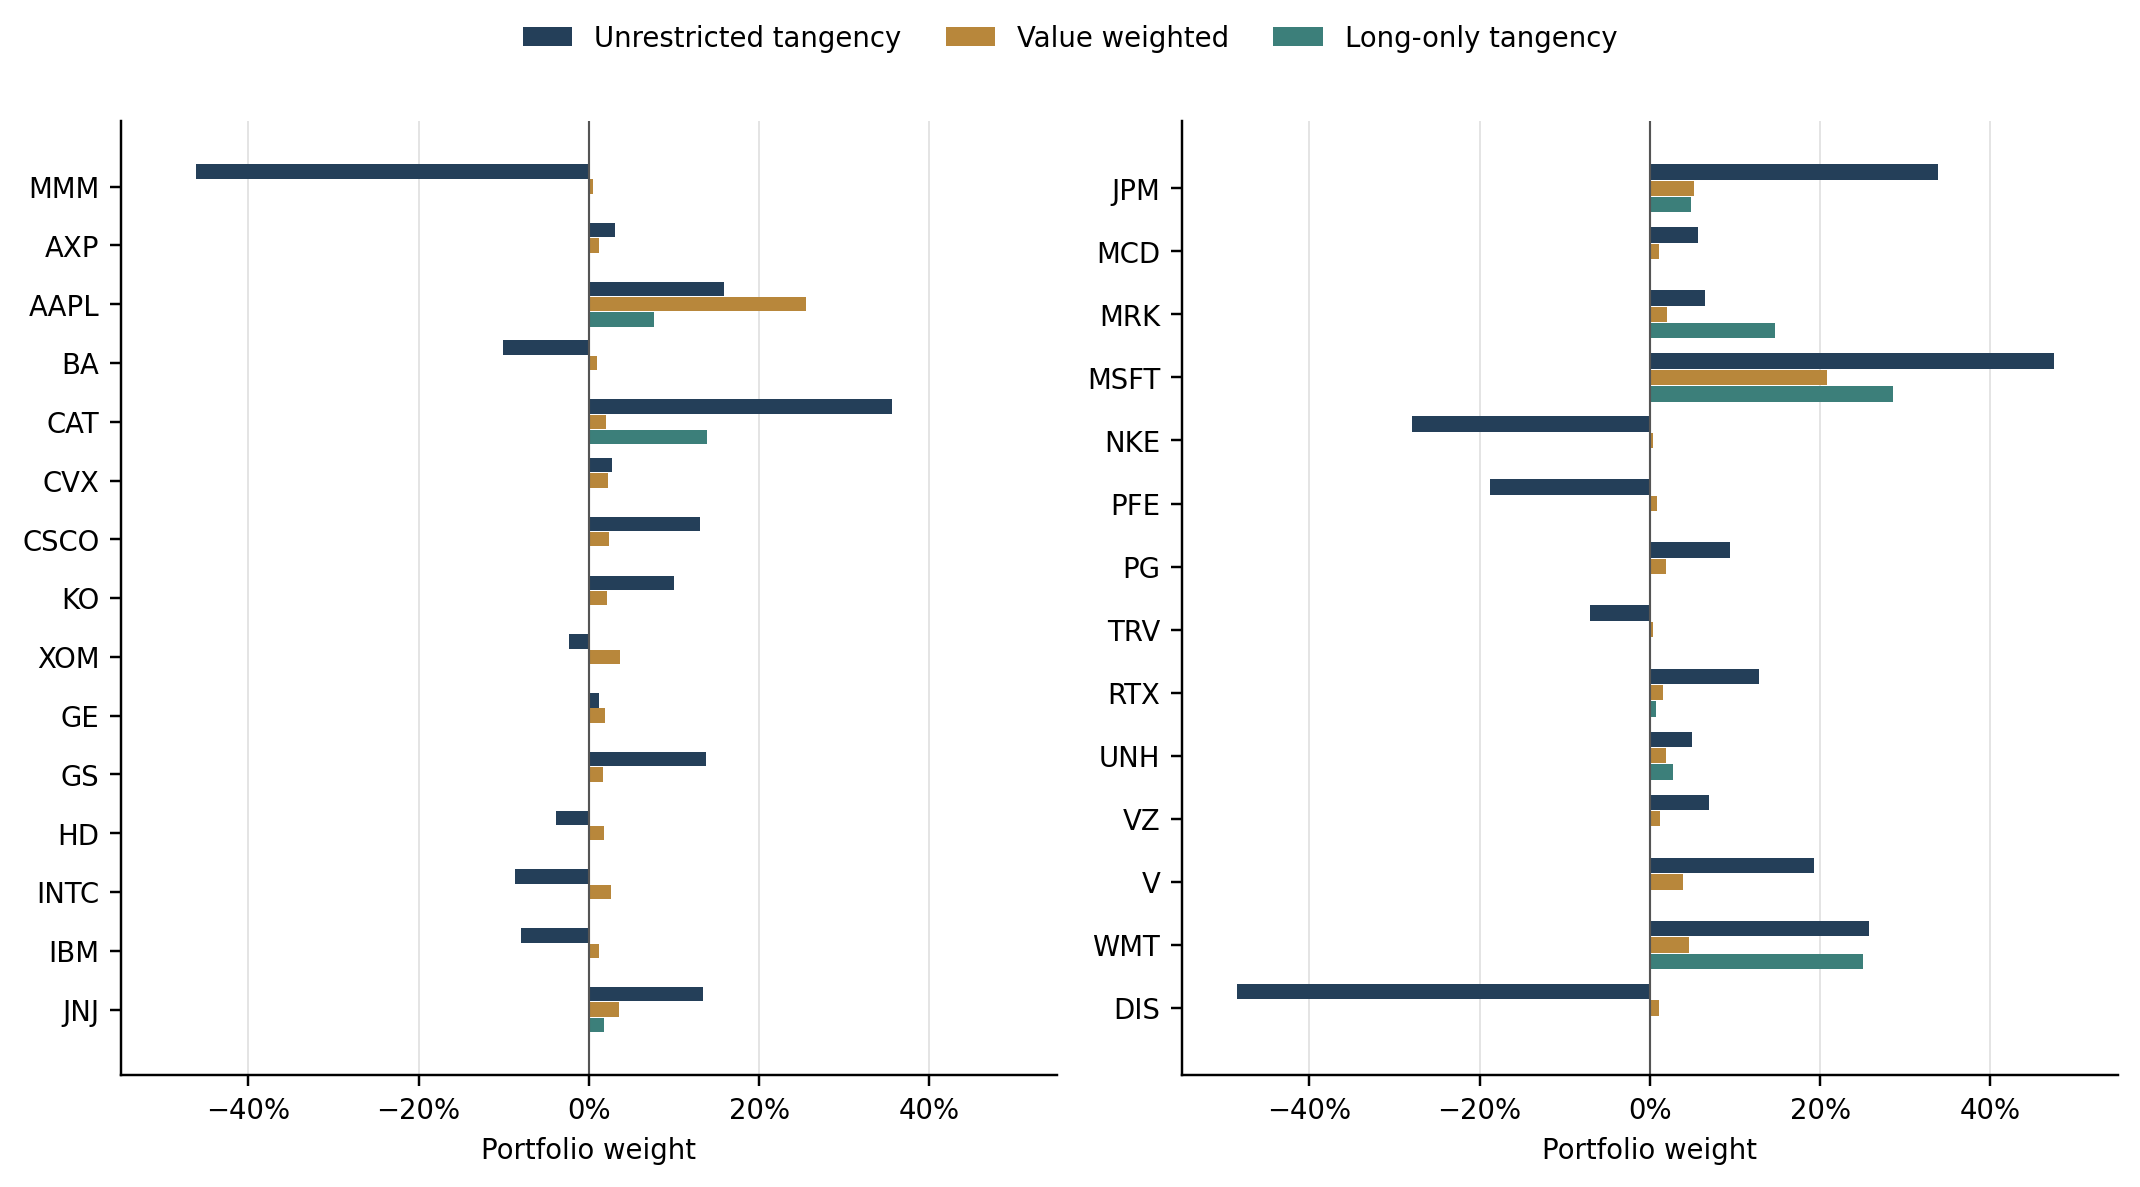

,Mean % (annual),Volatility % (annual),Model Sharpe,Gross %
Portfolio,,,,
Tangency (full sample),44.547,19.794,2.142,462.588
Value weighted (2026-08-31),20.790,15.712,1.186,100.000
Long-only tangency (full sample),22.207,13.946,1.438,100.000


,Tangency %,Value %,Long only %
ticker,,,
MMM,-46.178,0.489,0.000
AXP,3.084,1.230,0.000
AAPL,15.862,25.515,7.659
BA,-10.084,0.906,0.000
CAT,35.566,2.023,13.879
CVX,2.702,2.231,0.000
CSCO,13.066,2.404,0.000
KO,10.008,2.105,0.000
XOM,-2.343,3.652,0.000


In [3]:
display(Image(filename=str(ROOT / 'results/stage1/figures/exhibit_1b_three_portfolios.png'), width=960))
statistics = table('results/stage1/portfolio_statistics.csv')

def performance(frame):
    out = frame[['portfolio', 'annual_mean', 'annual_volatility',
                 'sharpe_model_annual', 'gross_exposure']].copy()
    out[['annual_mean', 'annual_volatility', 'gross_exposure']] *= 100
    out.columns = ['Portfolio', 'Mean % (annual)', 'Volatility % (annual)',
                   'Model Sharpe', 'Gross %']
    return out.round(3).set_index('Portfolio')

main_names = ['Tangency (full sample)', 'Value weighted (2026-08-31)',
              'Long-only tangency (full sample)']
main = statistics.query("evaluation_window == 'full_sample'")
main = main.set_index('portfolio').loc[main_names].reset_index()
display(performance(main))
weights = table('results/stage1/exhibit_1b_weights.csv').set_index('ticker')
display(weights.mul(100).round(3).rename(columns={
    'tangency_weight': 'Tangency %', 'value_weight': 'Value %',
    'long_only_weight': 'Long only %'}))

Tangency and value weighting produce markedly different allocations.
Unrestricted weights include large offsetting long and short positions, so
gross exposure exceeds net investment. The long-only constraint narrows the
feasible set and lowers the fitted maximum model Sharpe.

## 1c · A short discussion and re-estimation

Re-estimate mean, covariance and mean RF in two non-overlapping 65-month
windows: November 2015–March 2021 and April 2021–August 2026. Include the
full-sample fit as a common baseline. Each performance row below uses its
**own fitting window**.

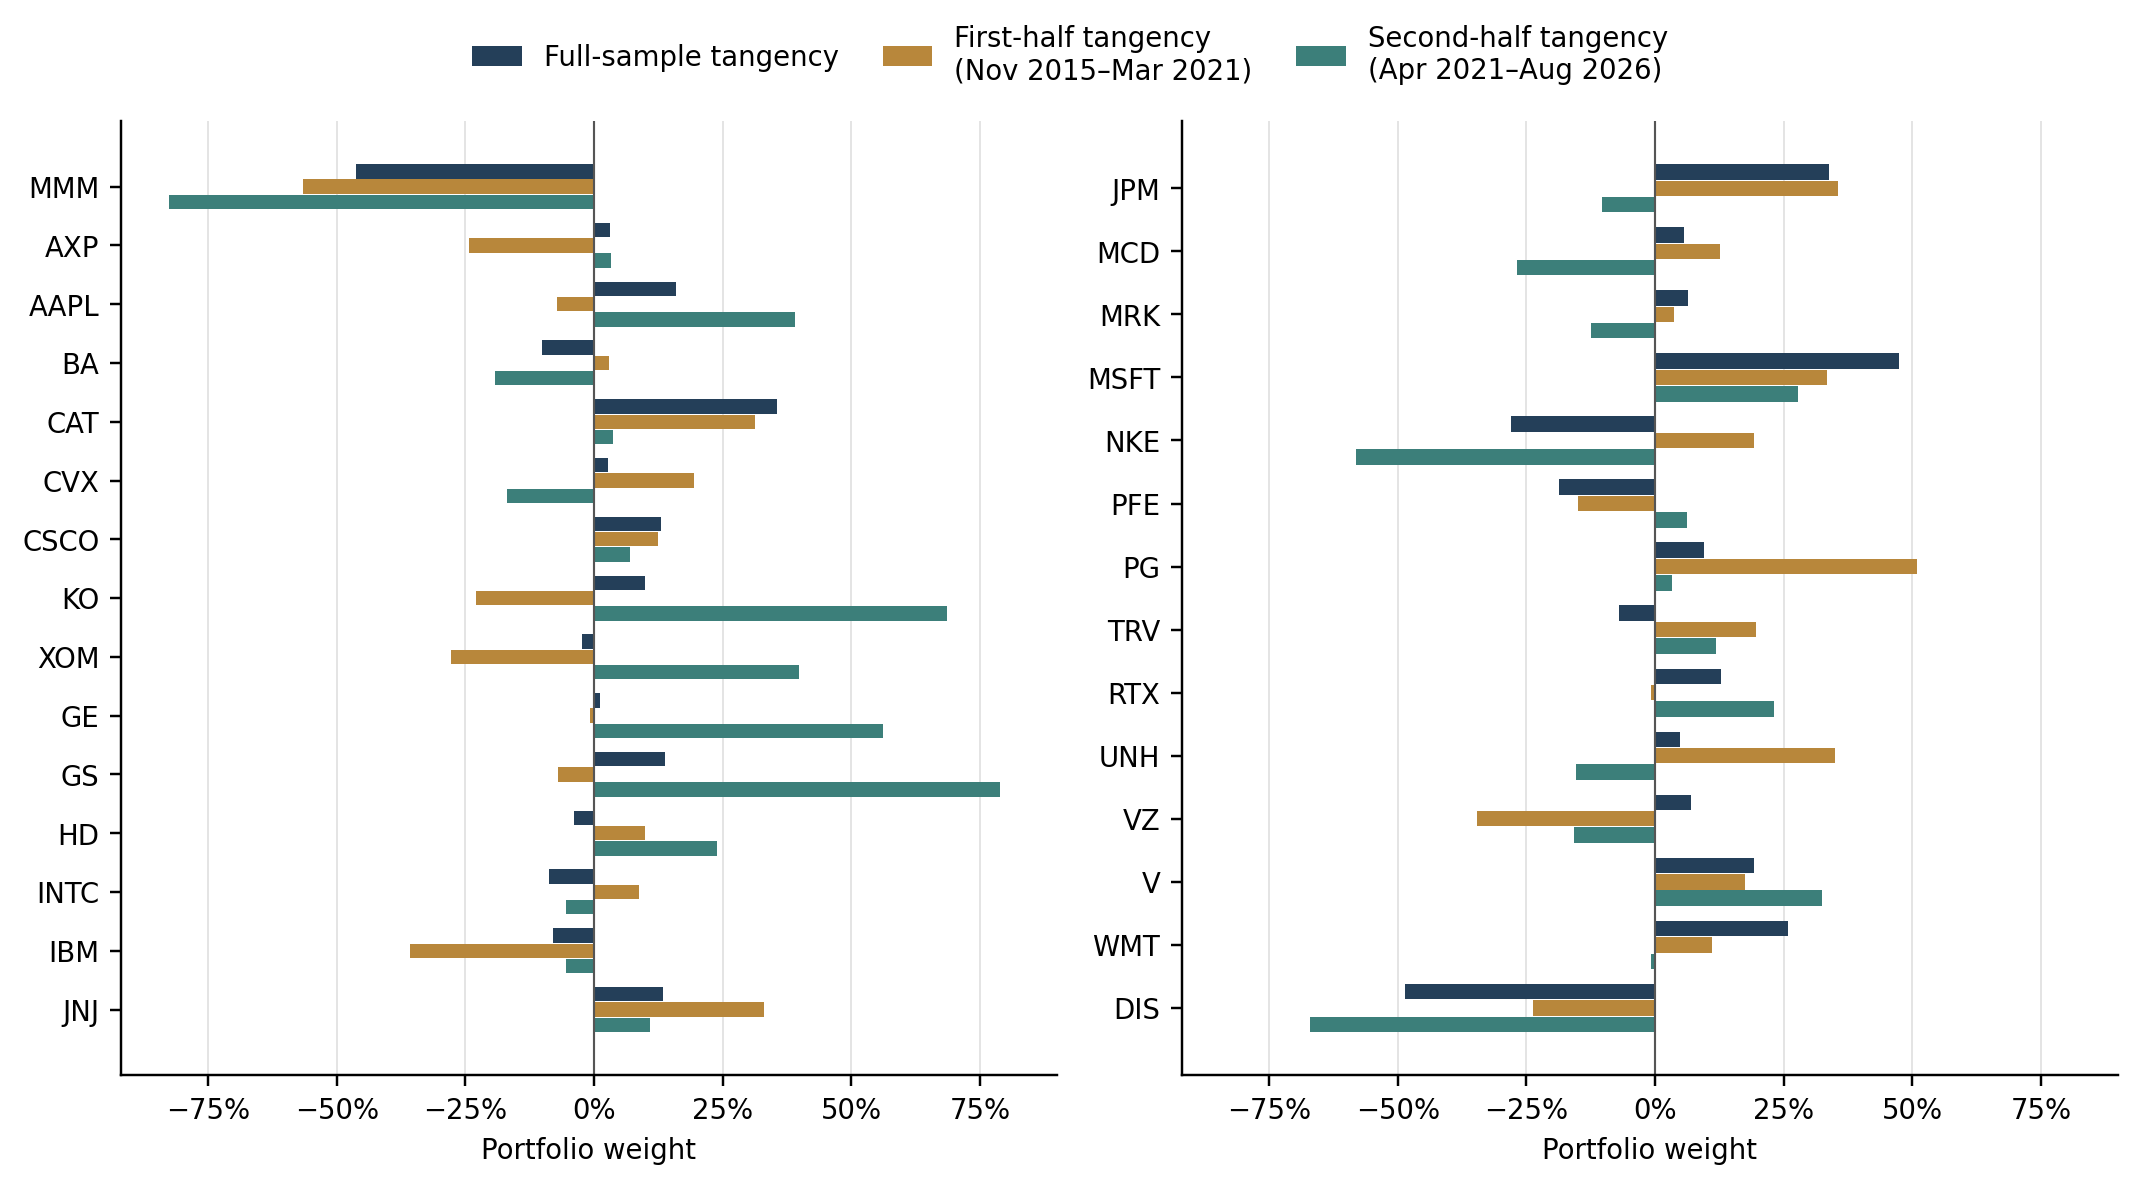

,Mean % (annual),Volatility % (annual),Model Sharpe,Gross %
Portfolio,,,,
Tangency (full sample),44.547,19.794,2.142,462.588
Tangency (first half),44.215,13.739,3.146,612.580
Tangency (second half),84.477,23.051,3.521,772.765


Weight correlation: 0.106
Sign changes: 17
First-half weights evaluated on second-half returns, model Sharpe: 0.432


In [4]:
display(Image(filename=str(ROOT / 'results/stage1/figures/time_weights_three_dated.png'), width=960))
fitted_rows = pd.concat([
    statistics.query("portfolio == 'Tangency (full sample)' and evaluation_window == 'full_sample'"),
    statistics.query("portfolio == 'Tangency (first half)' and evaluation_window == 'first_half'"),
    statistics.query("portfolio == 'Tangency (second half)' and evaluation_window == 'second_half'")
], ignore_index=True)
display(performance(fitted_rows))
time_weights = table('results/stage1/exhibit_1c_subsample_weights.csv').set_index('ticker')
first, second = time_weights['first_half_weight'], time_weights['second_half_weight']
print('Weight correlation:', round(first.corr(second), 3))
print('Sign changes:', int((np.sign(first) != np.sign(second)).sum()))
holdout = statistics.query("portfolio == 'Tangency (first half)' and evaluation_window == 'second_half'")
print('First-half weights evaluated on second-half returns, model Sharpe:',
      round(float(holdout.iloc[0]['sharpe_model_annual']), 3))

Sampling error and differences in market conditions across periods can both
contribute, so this exercise does not completely identify the effects of mean
and covariance estimation errors. Fitted half-sample performance and applying
first-half weights to second-half returns use different evaluation windows.

### Universe sensitivity

Keep the full 130-month window fixed and independently fit the primary 29,
the retained 23 and six later-removal stocks. These subset fits are not rescaled
pieces of the 29-stock weights. Outside-subset CSV entries remain missing;
the plot uses zero to show that those stocks are not held.

The retained-23 and all-29 common-stock weights correlate 0.983, with only
two sign changes. The six-stock fitted Sharpe is 0.725 versus 2.071 for the
retained 23. This difference is better interpreted as reflecting distinct
investment opportunity sets rather than directly indicating the relative size
of estimation errors.

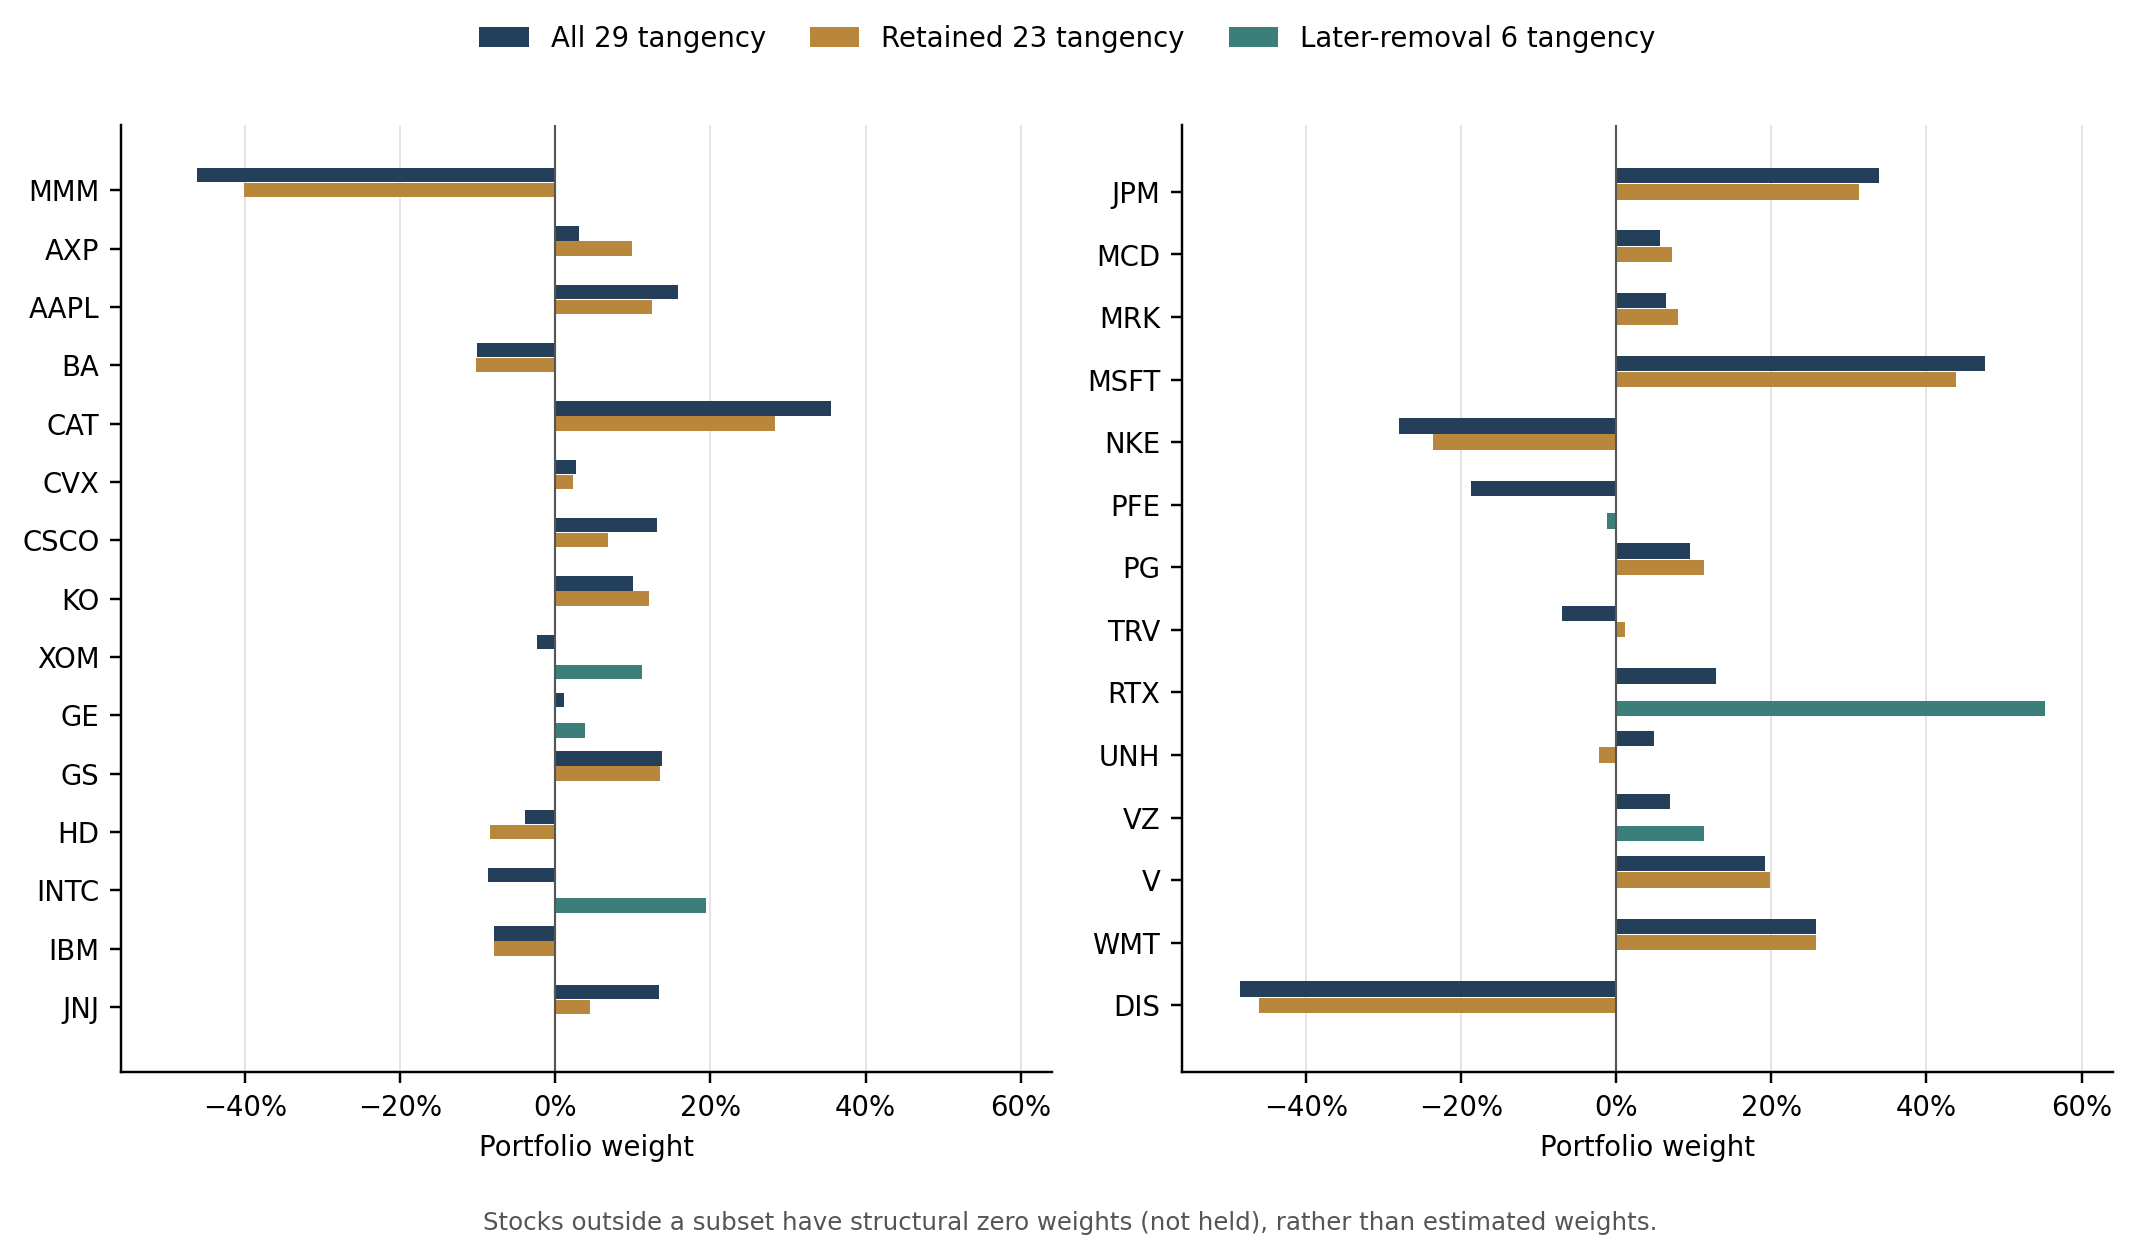

,Mean % (annual),Volatility % (annual),Model Sharpe,Gross %
Portfolio,,,,
All 29 tangency,44.547,19.794,2.142,462.588
Retained 23 tangency,40.144,18.350,2.071,376.473
Later-removal 6 tangency,17.298,20.907,0.725,102.224


In [5]:
display(Image(filename=str(ROOT / 'results/stage1/universe_sensitivity/figures/weights_three.png'), width=960))
universe_stats = table('results/stage1/universe_sensitivity/portfolio_statistics.csv')
display(performance(universe_stats.rename(columns={'model_sharpe_annual': 'sharpe_model_annual'})))

## Next stage inputs

For Stage 2, use the raw monthly portfolio return series and subtract the
aligned monthly RF exactly once. `Mkt-RF` is already an excess return. Weekly
returns and weekly factors still require preparation and validation; weekly
robustness has not been run. Follow the [handoff contract](../docs/COLLABORATOR_HANDOFF.md).

In [6]:
portfolio_returns = table('results/stage1/portfolio_monthly_returns.csv').set_index('Month')
assert portfolio_returns.index.equals(factors.index)
stage2_inputs = factors[['Mkt-RF', 'SMB', 'HML']].copy()
stage2_inputs.insert(0, 'portfolio_excess',
                     portfolio_returns['Tangency (full sample)'] - factors['RF'])
assert not stage2_inputs.isna().any().any()
display(stage2_inputs.head())
print('Stage 2 input example: decimal monthly excess returns, no regression fitted here.')

,portfolio_excess,Mkt-RF,SMB,HML
Month,,,,
2015-11,0.024413,0.0057,0.0358,-0.0043
2015-12,0.054169,-0.0215,-0.0280,-0.0257
2016-01,-0.004470,-0.0574,-0.0340,0.0208
2016-02,-0.023401,-0.0006,0.0073,-0.0061
2016-03,0.122078,0.0695,0.0075,0.0123


Stage 2 input example: decimal monthly excess returns, no regression fitted here.
